[8.05 8.04 8.03 8.02 8.09 8.13]
[20.12 20.12 20.09 20.07 20.07 20.07]


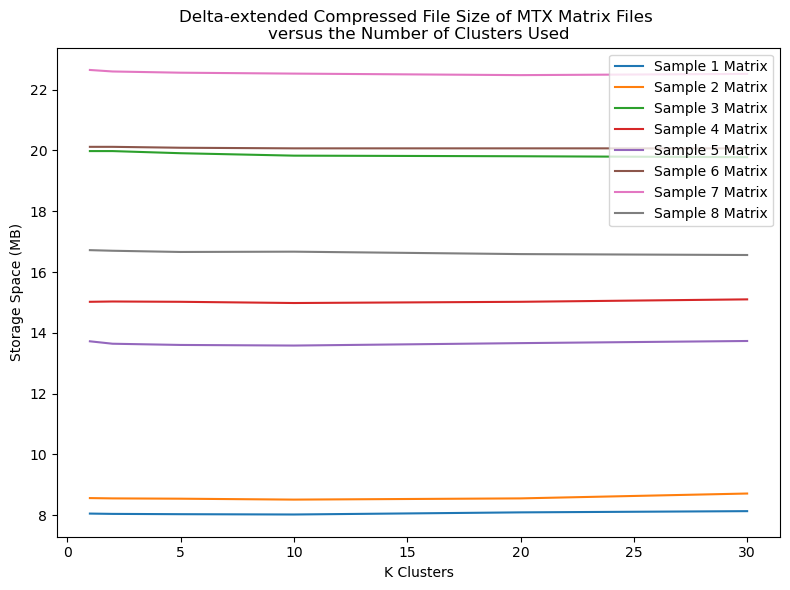

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

in_path = 'compressed/neural/'

def get_size(start_path = '.'):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(start_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            # skip if it is symbolic link
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return round(total_size/1000000,2)

data = []
for sample in range(1,9):
    dir = os.path.join(in_path, 'sample'+str(sample))
    line_data = []
    for sub in os.listdir(dir):
        path = os.path.join(dir, sub, 'low_level_compress')
        size = get_size(path)
        line_data.append([sample, int(sub[1:]), size])
    line_data.sort()
    line_data = np.array(line_data)
    data.append(line_data)
print(data[0][:,2])

plt.figure(figsize=(8, 6))
for i, d in enumerate(data):
    plt.plot([1, 2, 5, 10, 20, 30], d[:,2], label=f'Sample {i+1} Matrix')
plt.legend(loc='upper right')
plt.xlabel('K Clusters')
plt.ylabel('Storage Space (MB)')
plt.title('Compressed File Size of MTX Matrix Files \nversus the Number of Clusters Used')
plt.tight_layout()
plt.savefig('storage_vs_k_clusters.png')
print(data[5][:,2])

0.008261630539882159


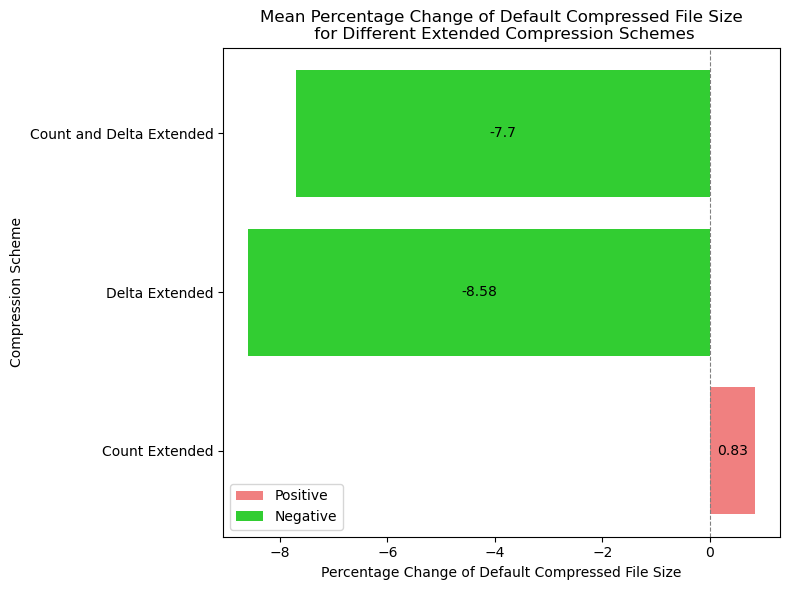

In [153]:
in_path = 'compressed/neural/'

def get_size(start_path = '.'):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(start_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            # skip if it is symbolic link
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return round(total_size/1000000,2)

default = []
count_extended = []
delta_extended = []
both_extended = []
for sample in range(1,9):
    dir = os.path.join(in_path, 'sample'+str(sample))
    for sub in os.listdir(dir):
        path1 = os.path.join(dir, sub, 'low_level_compress')
        path2 = os.path.join(dir, sub, 'low_level_compress_count_extension')
        path3 = os.path.join(dir, sub, 'low_level_compress_delta_extension')
        path4 = os.path.join(dir, sub, 'low_level_compress_count_and_delta_extension')
        default.append(get_size(path1))
        count_extended.append(get_size(path2))
        delta_extended.append(get_size(path3))
        both_extended.append(get_size(path4))

delta_percentage = np.mean(delta_extended)/np.mean(default) - 1
count_percentage = np.mean(count_extended)/np.mean(default) - 1
both_percentage = np.mean(both_extended)/np.mean(default) - 1
print(count_percentage)

import matplotlib.pyplot as plt
import numpy as np

# Sample data
categories = ['Count Extended', 'Delta Extended', 'Count and Delta Extended']
values = [count_percentage, delta_percentage, both_percentage]  # Example with positive and negative values
values = [round(v*100, 2) for v in values]

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars for positive values
# These bars will extend to the right from the y-axis
bars_positive = ax.barh(
    categories[0],
    [values[0]],
    color='lightcoral',
    label='Positive'
)

# Plot bars for negative values
# These bars will extend to the left from the y-axis
bars_negative = ax.barh(
    categories[1:],
    values[1:],
    color='limegreen',
    label='Negative'
)

# Add a vertical line at x=0 for visual separation
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)

ax.bar_label(bars_negative, label_type='center')
ax.bar_label(bars_positive, label_type='center')

# Customize the plot
ax.set_xlabel('Percentage Change of Default Compressed File Size')
ax.set_ylabel('Compression Scheme')
ax.set_title('Mean Percentage Change of Default Compressed File Size\n for Different Extended Compression Schemes')
ax.legend()
plt.tight_layout()
plt.savefig('percentage_change.png')
plt.show()